# EXP-003 — Baseline Classifiers
Logistic Regression and Random Forest on raw 16 scaled EEG channel features.
Establishes a performance floor before the full FFT+UMAP+SeqBoostNet pipeline.

In [1]:
import sys
sys.path.insert(0, str(__import__('pathlib').Path('..').resolve()))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

from src.beed.data import load_raw, split
from src.beed.features import scale
from src.beed.config import CLASS_LABELS, CHANNEL_NAMES, DATA_PROCESSED, FIGURES, RANDOM_STATE

FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_theme(style='whitegrid')
print('Ready.')

Ready.


## 1. Load & split

In [2]:
df = load_raw()
train, val, test = split(df)

X_train_raw = train.drop(columns=['y'])
y_train      = train['y']
X_val_raw   = val.drop(columns=['y'])
y_val        = val['y']
X_test_raw  = test.drop(columns=['y'])
y_test       = test['y']

print(f'Train: {X_train_raw.shape}  Val: {X_val_raw.shape}  Test: {X_test_raw.shape}')
print(f'Classes: {sorted(y_train.unique())}  (counts: {y_train.value_counts().sort_index().to_dict()})')

Train: (5600, 16)  Val: (800, 16)  Test: (1600, 16)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  (counts: {0: 1400, 1: 1400, 2: 1400, 3: 1400})


## 2. Scale raw 16 features
Fit StandardScaler on train only; transform val and test.

In [3]:
X_train, scaler = scale(X_train_raw, fit=True)
X_val,   _      = scale(X_val_raw,  scaler=scaler, fit=False)
X_test,  _      = scale(X_test_raw, scaler=scaler, fit=False)

print(f'Feature matrix shape — train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')
print(f'Columns: {list(X_train.columns)}')

Feature matrix shape — train: (5600, 16), val: (800, 16), test: (1600, 16)
Columns: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6']


## 3. Train classifiers

In [4]:
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0,
)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    lr.fit(X_train, y_train)
print('Logistic Regression fitted.')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
print('Random Forest fitted.')

Logistic Regression fitted.


Random Forest fitted.


## 4. Evaluate on validation set

In [5]:
label_names = [CLASS_LABELS[i] for i in sorted(CLASS_LABELS)]

for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    preds = clf.predict(X_val)
    print(f'=== {name} — Validation ===')
    print(classification_report(y_val, preds, target_names=label_names))
    print()

=== Logistic Regression — Validation ===
                precision    recall  f1-score   support

       Healthy       0.81      0.47      0.60       200
         Focal       0.52      0.64      0.58       200
   Generalized       0.37      0.40      0.38       200
Seizure Events       0.38      0.41      0.40       200

      accuracy                           0.48       800
     macro avg       0.52      0.48      0.49       800
  weighted avg       0.52      0.48      0.49       800


=== Random Forest — Validation ===
                precision    recall  f1-score   support

       Healthy       1.00      0.98      0.99       200
         Focal       0.96      0.96      0.96       200
   Generalized       0.91      0.94      0.92       200
Seizure Events       0.92      0.91      0.91       200

      accuracy                           0.95       800
     macro avg       0.95      0.95      0.95       800
  weighted avg       0.95      0.95      0.95       800




## 5. Confusion matrices — validation set

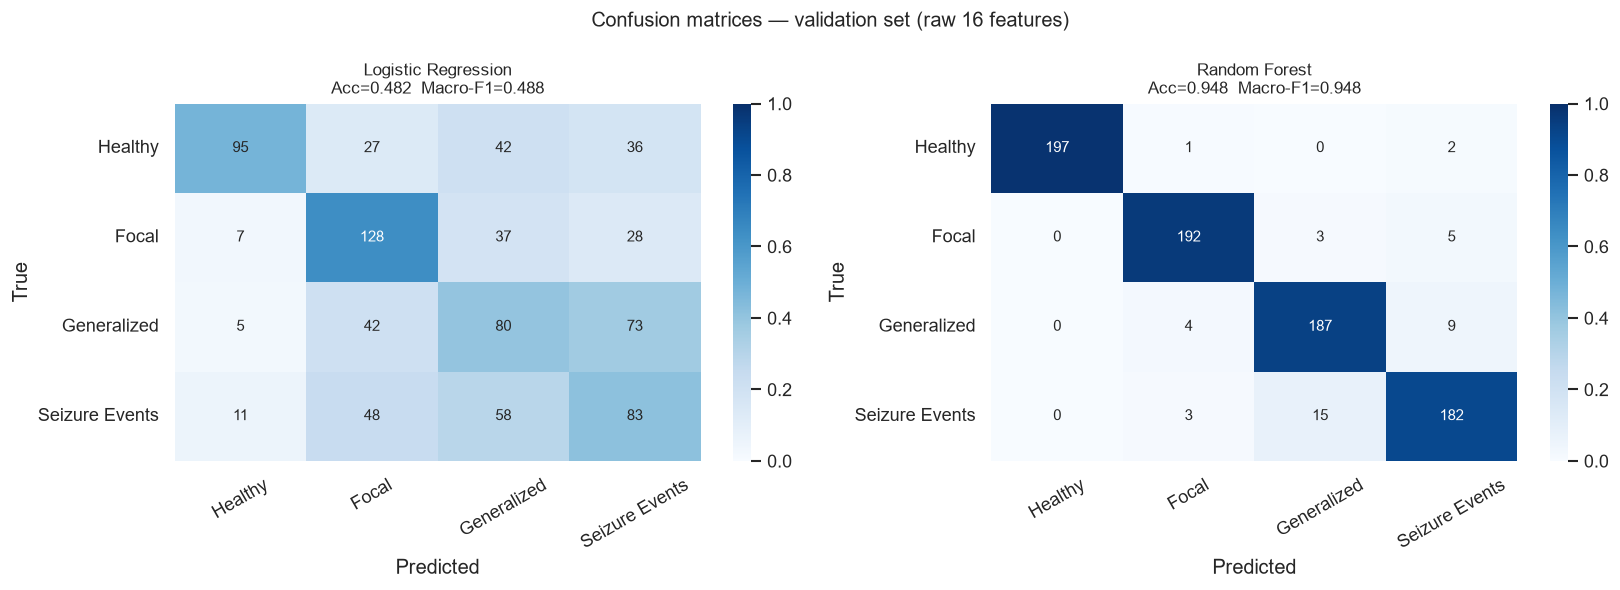

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, clf) in zip(axes, [('Logistic Regression', lr), ('Random Forest', rf)]):
    preds = clf.predict(X_val)
    cm = confusion_matrix(y_val, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', ax=ax,
        xticklabels=label_names, yticklabels=label_names,
        cmap='Blues', vmin=0, vmax=1,
        annot_kws={'size': 9},
    )
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='macro')
    ax.set_title(f'{name}\nAcc={acc:.3f}  Macro-F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Confusion matrices — validation set (raw 16 features)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '11_baseline_confusion_val.png', bbox_inches='tight')
plt.show()

## 6. Evaluate on test set

In [7]:
for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    preds = clf.predict(X_test)
    print(f'=== {name} — Test ===')
    print(classification_report(y_test, preds, target_names=label_names))
    print()

=== Logistic Regression — Test ===
                precision    recall  f1-score   support

       Healthy       0.79      0.51      0.62       400
         Focal       0.50      0.59      0.54       400
   Generalized       0.38      0.41      0.39       400
Seizure Events       0.31      0.33      0.32       400

      accuracy                           0.46      1600
     macro avg       0.49      0.46      0.47      1600
  weighted avg       0.49      0.46      0.47      1600


=== Random Forest — Test ===
                precision    recall  f1-score   support

       Healthy       1.00      0.99      0.99       400
         Focal       0.96      0.96      0.96       400
   Generalized       0.92      0.95      0.93       400
Seizure Events       0.93      0.92      0.92       400

      accuracy                           0.95      1600
     macro avg       0.95      0.95      0.95      1600
  weighted avg       0.95      0.95      0.95      1600




## 7. Confusion matrices — test set

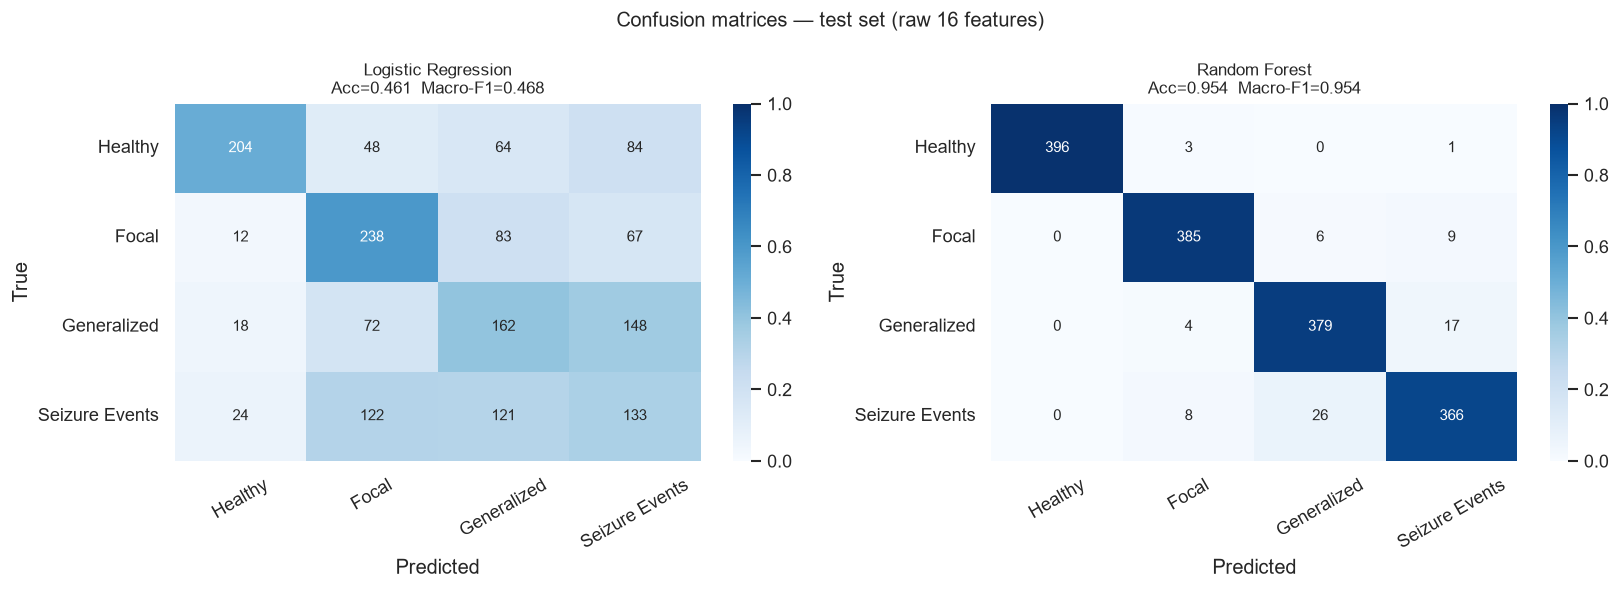

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, clf) in zip(axes, [('Logistic Regression', lr), ('Random Forest', rf)]):
    preds = clf.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', ax=ax,
        xticklabels=label_names, yticklabels=label_names,
        cmap='Blues', vmin=0, vmax=1,
        annot_kws={'size': 9},
    )
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    ax.set_title(f'{name}\nAcc={acc:.3f}  Macro-F1={f1:.3f}', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Confusion matrices — test set (raw 16 features)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / '12_baseline_confusion_test.png', bbox_inches='tight')
plt.show()

## 8. Feature importances — Random Forest

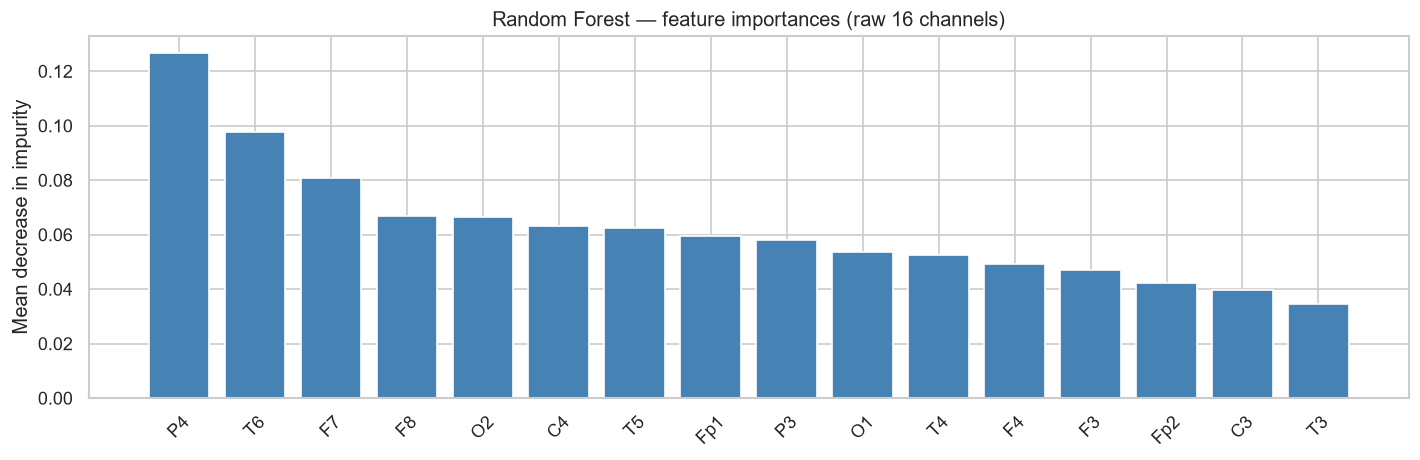

Top 5 channels by importance:
P4    0.126511
T6    0.097812
F7    0.080911
F8    0.066712
O2    0.066333


In [9]:
importances = pd.Series(rf.feature_importances_, index=CHANNEL_NAMES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(importances.index, importances.values, color='steelblue')
ax.set_ylabel('Mean decrease in impurity')
ax.set_title('Random Forest — feature importances (raw 16 channels)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / '13_rf_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 channels by importance:')
print(importances.head().to_string())

## 9. Summary table

In [10]:
rows = []
for name, clf in [('Logistic Regression', lr), ('Random Forest', rf)]:
    for split_name, X_s, y_s in [('val', X_val, y_val), ('test', X_test, y_test)]:
        preds = clf.predict(X_s)
        rows.append({
            'model': name,
            'split': split_name,
            'accuracy': round(accuracy_score(y_s, preds), 4),
            'macro_f1': round(f1_score(y_s, preds, average='macro'), 4),
            'weighted_f1': round(f1_score(y_s, preds, average='weighted'), 4),
        })

results = pd.DataFrame(rows)
results_path = DATA_PROCESSED / 'exp003_baseline_results.csv'
results.to_csv(results_path, index=False)
print(f'Saved results → {results_path}')
results

Saved results → C:\dev\BEED\data\processed\exp003_baseline_results.csv


,model,split,accuracy,macro_f1,weighted_f1
0,Logistic Regression,val,0.4825,0.4879,0.4879
1,Logistic Regression,test,0.4606,0.4678,0.4678
2,Random Forest,val,0.9475,0.9476,0.9476
3,Random Forest,test,0.9537,0.9538,0.9538


## 10. Val vs Test accuracy — bar chart

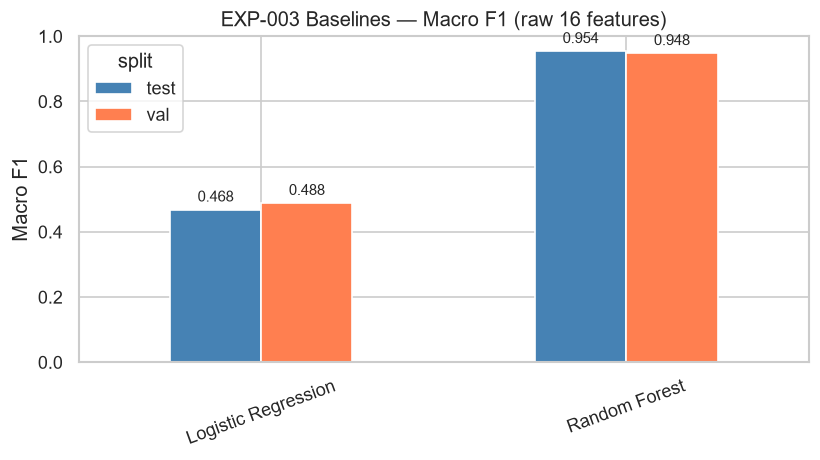

In [11]:
pivot = results.pivot(index='model', columns='split', values='macro_f1')

fig, ax = plt.subplots(figsize=(7, 4))
pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
ax.set_ylim(0, 1)
ax.set_ylabel('Macro F1')
ax.set_title('EXP-003 Baselines — Macro F1 (raw 16 features)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=20)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / '14_baseline_macro_f1.png', bbox_inches='tight')
plt.show()

## 11. Summary

In [12]:
print('=== EXP-003 Summary ===')
print('Feature set : raw 16 EEG channels, StandardScaler (fit on train only)')
print(f'Train / Val / Test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]} samples')
print()
for _, row in results[results['split'] == 'test'].iterrows():
    print(f"{row['model']:25s}  test acc={row['accuracy']:.4f}  macro-F1={row['macro_f1']:.4f}")
print()
print('These results serve as the baseline floor.')
print('EXP-004 will run the same classifiers on the 19-feature FFT+UMAP matrix.')

=== EXP-003 Summary ===
Feature set : raw 16 EEG channels, StandardScaler (fit on train only)
Train / Val / Test : 5600 / 800 / 1600 samples

Logistic Regression        test acc=0.4606  macro-F1=0.4678
Random Forest              test acc=0.9537  macro-F1=0.9538

These results serve as the baseline floor.
EXP-004 will run the same classifiers on the 19-feature FFT+UMAP matrix.
